# Exercise 2 — Non-Linearity in Higher Dimensions

Runnable code for the *Data* deliverable. Two 5-dimensional, two-class datasets
are contrasted: **Dataset I** (two shifted multivariate Gaussians) is essentially
linearly separable, while **Dataset II** (two concentric spherical shells) is not
separable by any hyperplane even though it is trivially separable by radius. All
randomness comes from a single fixed generator so the results are reproducible.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

%matplotlib inline

rng = np.random.default_rng(42)

FIG_DIR = Path("..") / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

N = 500  # samples per class
COLORS = {"A": "#1f77b4", "B": "#d62728", "C": "#2ca02c", "D": "#9467bd"}

## A — Dataset I: shifted Gaussians

500 samples per class from multivariate normals with the given means and
covariances. Class A is centered at the origin; Class B is shifted to
$[1.5]^5$ and has larger variances and a **negative** correlation between the
first two features (Class A's is positive).

In [2]:
mu_A = np.zeros(5)
Sigma_A = np.array([
    [1.0, 0.8, 0.1, 0.0, 0.0],
    [0.8, 1.0, 0.3, 0.0, 0.0],
    [0.1, 0.3, 1.0, 0.5, 0.0],
    [0.0, 0.0, 0.5, 1.0, 0.2],
    [0.0, 0.0, 0.0, 0.2, 1.0],
])

mu_B = np.full(5, 1.5)
Sigma_B = np.array([
    [ 1.5, -0.7, 0.2, 0.0, 0.0],
    [-0.7,  1.5, 0.4, 0.0, 0.0],
    [ 0.2,  0.4, 1.5, 0.6, 0.0],
    [ 0.0,  0.0, 0.6, 1.5, 0.3],
    [ 0.0,  0.0, 0.0, 0.3, 1.5],
])

X_A = rng.multivariate_normal(mu_A, Sigma_A, size=N)
X_B = rng.multivariate_normal(mu_B, Sigma_B, size=N)

X1 = np.vstack([X_A, X_B])
y1 = np.array([0] * N + [1] * N)
print("Dataset I:", X1.shape, "| Class A:", X_A.shape, "| Class B:", X_B.shape)

Dataset I: (1000, 5) | Class A: (500, 5) | Class B: (500, 5)


## B — Dataset II: concentric shells

Directions drawn uniformly on the unit sphere of $\mathbb{R}^5$
($v \sim \mathcal{N}(0, I_5)$, then $u = v / \Vert v \Vert$), scaled by a
random radius. Class C is the inner core (radius $\approx 2$), Class D the outer
shell (radius $\approx 5$). I read $\mathcal{N}(\mu, 0.4)$ as *standard
deviation* $0.4$.

In [3]:
def sample_shell(radius_mean, radius_std, n):
    v = rng.standard_normal((n, 5))
    u = v / np.linalg.norm(v, axis=1, keepdims=True)   # uniform on unit sphere
    rho = rng.normal(radius_mean, radius_std, size=n)
    return rho[:, None] * u


X_C = sample_shell(2.0, 0.4, N)   # core
X_D = sample_shell(5.0, 0.4, N)   # shell

X2 = np.vstack([X_C, X_D])
y2 = np.array([0] * N + [1] * N)
print("Dataset II:", X2.shape, "| Class C:", X_C.shape, "| Class D:", X_D.shape)

Dataset II: (1000, 5) | Class C: (500, 5) | Class D: (500, 5)


## C — Visualize and compare

### Figure 4 — PCA projection to 2D

PCA is fit on each full dataset (both classes) and used to project to the first
two principal components.

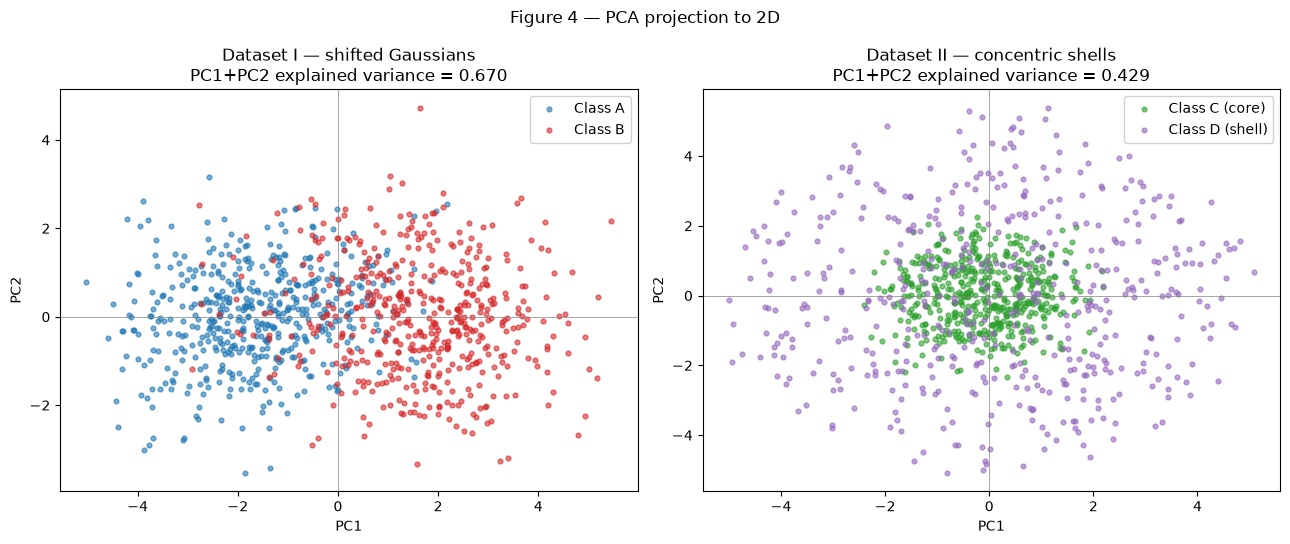

Dataset I  explained variance PC1, PC2 = [0.513 0.158]  sum = 0.670
Dataset II explained variance PC1, PC2 = [0.216 0.213]  sum = 0.429


In [4]:
pca1 = PCA(n_components=2).fit(X1)
Z1 = pca1.transform(X1)
pca2 = PCA(n_components=2).fit(X2)
Z2 = pca2.transform(X2)

evr1 = pca1.explained_variance_ratio_
evr2 = pca2.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].scatter(Z1[y1 == 0, 0], Z1[y1 == 0, 1], s=12, alpha=0.6,
                color=COLORS["A"], label="Class A")
axes[0].scatter(Z1[y1 == 1, 0], Z1[y1 == 1, 1], s=12, alpha=0.6,
                color=COLORS["B"], label="Class B")
axes[0].set_title(f"Dataset I — shifted Gaussians\n"
                  f"PC1+PC2 explained variance = {evr1.sum():.3f}")
axes[1].scatter(Z2[y2 == 0, 0], Z2[y2 == 0, 1], s=12, alpha=0.6,
                color=COLORS["C"], label="Class C (core)")
axes[1].scatter(Z2[y2 == 1, 0], Z2[y2 == 1, 1], s=12, alpha=0.6,
                color=COLORS["D"], label="Class D (shell)")
axes[1].set_title(f"Dataset II — concentric shells\n"
                  f"PC1+PC2 explained variance = {evr2.sum():.3f}")
for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(loc="upper right", framealpha=0.9)
    ax.axhline(0, color="grey", lw=0.5)
    ax.axvline(0, color="grey", lw=0.5)
fig.suptitle("Figure 4 — PCA projection to 2D")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_pca.png", dpi=150)
plt.show()

print(f"Dataset I  explained variance PC1, PC2 = {evr1.round(3)}  sum = {evr1.sum():.3f}")
print(f"Dataset II explained variance PC1, PC2 = {evr2.round(3)}  sum = {evr2.sum():.3f}")

### Distance between class centers, and Figure 5 (radius histograms)

Both computed in the full 5D space.

Dataset I  ||center_A - center_B|| = 3.264
Dataset II ||center_C - center_D|| = 0.266


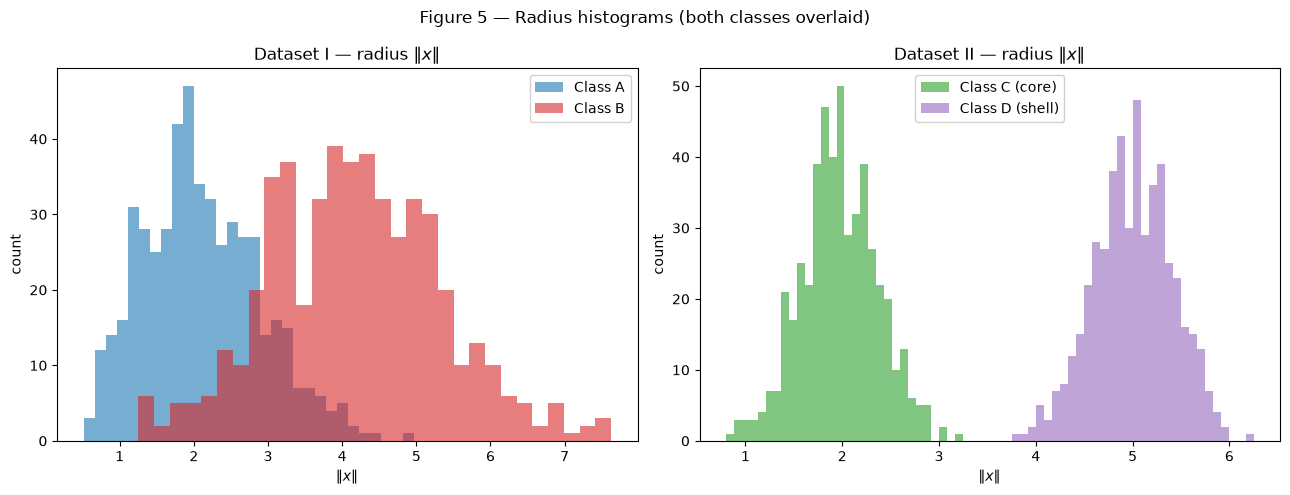

In [5]:
center_dist1 = np.linalg.norm(X_A.mean(0) - X_B.mean(0))
center_dist2 = np.linalg.norm(X_C.mean(0) - X_D.mean(0))
print(f"Dataset I  ||center_A - center_B|| = {center_dist1:.3f}")
print(f"Dataset II ||center_C - center_D|| = {center_dist2:.3f}")

rA, rB = np.linalg.norm(X_A, axis=1), np.linalg.norm(X_B, axis=1)
rC, rD = np.linalg.norm(X_C, axis=1), np.linalg.norm(X_D, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(rA, bins=30, alpha=0.6, color=COLORS["A"], label="Class A")
axes[0].hist(rB, bins=30, alpha=0.6, color=COLORS["B"], label="Class B")
axes[0].set_title("Dataset I — radius $\\Vert x \\Vert$")
axes[1].hist(rC, bins=30, alpha=0.6, color=COLORS["C"], label="Class C (core)")
axes[1].hist(rD, bins=30, alpha=0.6, color=COLORS["D"], label="Class D (shell)")
axes[1].set_title("Dataset II — radius $\\Vert x \\Vert$")
for ax in axes:
    ax.set_xlabel("$\\Vert x \\Vert$")
    ax.set_ylabel("count")
    ax.legend(framealpha=0.9)
fig.suptitle("Figure 5 — Radius histograms (both classes overlaid)")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_radius.png", dpi=150)
plt.show()


## D — Analysis: a function that separates Dataset II

PCA (a *linear* map) mixes the two shells, yet a single **quadratic** feature
$f(x) = \Vert x \Vert^2 = \sum_i x_i^2$ separates them cleanly. With classes
at radius $\approx 2$ and $\approx 5$, the natural threshold sits at radius
$3.5$, i.e. $f(x) = 3.5^2 = 12.25$.

In [6]:
f = (X2 ** 2).sum(axis=1)          # squared radius
threshold = 3.5 ** 2                # midpoint radius 3.5 -> 12.25
pred = (f > threshold).astype(int)  # 1 = shell (Class D)
accuracy = float(np.mean(pred == y2))
print(f"Separating rule: predict 'shell' when sum(x_i^2) > {threshold:.2f}")
print(f"Accuracy on Dataset II = {accuracy:.4f}")

Separating rule: predict 'shell' when sum(x_i^2) > 12.25
Accuracy on Dataset II = 1.0000
